In [ ]:
import numpy as np

P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46],
    [0.0,  1.0,  0.0,  0.0,  0.0 ],
    [0.16, 0.16, 0.22, 0.20, 0.26],  # x=0.20
    [0.0,  0.0,  0.0,  1.0,  0.0 ],
    [0.21, 0.27, 0.18, 0.24, 0.10]
])

row_sums = P.sum(axis=1)
row_sums


array([1., 1., 1., 1., 1.])

In [ ]:
import numpy as np

# Transition matrix with x=0.20
P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46],
    [0.0,  1.0,  0.0,  0.0,  0.0 ],
    [0.16, 0.16, 0.22, 0.20, 0.26],
    [0.0,  0.0,  0.0,  1.0,  0.0 ],
    [0.21, 0.27, 0.18, 0.24, 0.10]
])

# Initial distribution pi^(0)
pi0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03])

# Helper: evolve one step
def evolve(pi, P, steps=1):
    pi_n = pi.copy()
    for _ in range(steps):
        pi_n = pi_n @ P
    return pi_n

pi1 = evolve(pi0, P, 1)
pi2 = evolve(pi1, P, 1)
pi3 = evolve(pi2, P, 1)

pi0, pi1, pi2, pi3


(array([0.13, 0.24, 0.32, 0.28, 0.03]),
 array([0.0848, 0.3084, 0.0953, 0.3655, 0.146 ]),
 array([0.063716, 0.369004, 0.059966, 0.428928, 0.078386]),
 array([0.03943598, 0.4042229 , 0.0368594 , 0.4667426 , 0.05273912]))

In [ ]:
for n, pi in enumerate([pi0, pi1, pi2, pi3]):
    print(f"pi^{n} =", np.round(pi, 4), "sum =", pi.sum())


pi^0 = [0.13 0.24 0.32 0.28 0.03] sum = 1.0
pi^1 = [0.0848 0.3084 0.0953 0.3655 0.146 ] sum = 1.0
pi^2 = [0.0637 0.369  0.06   0.4289 0.0784] sum = 1.0000000000000002
pi^3 = [0.0394 0.4042 0.0369 0.4667 0.0527] sum = 1.0


In [ ]:
import numpy as np

P = np.array([
    [0.21, 0.07, 0.15, 0.11, 0.46],  # A
    [0.0,  1.0,  0.0,  0.0,  0.0 ],  # B (absorbing)
    [0.16, 0.16, 0.22, 0.20, 0.26],  # C
    [0.0,  0.0,  0.0,  1.0,  0.0 ],  # D (absorbing)
    [0.21, 0.27, 0.18, 0.24, 0.10]   # E
])

# New order indices: B=1, D=3, A=0, C=2, E=4
order = [1, 3, 0, 2, 4]
P_canon = P[np.ix_(order, order)]
P_canon


array([[1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.07, 0.11, 0.21, 0.15, 0.46],
       [0.16, 0.2 , 0.16, 0.22, 0.26],
       [0.27, 0.24, 0.21, 0.18, 0.1 ]])

In [ ]:
# Number of absorbing states
m = 2  # B, D
# Total states = 5

I = P_canon[:m, :m]
zero_block = P_canon[:m, m:]
R = P_canon[m:, :m]
Q = P_canon[m:, m:]

I, zero_block, R, Q


(array([[1., 0.],
        [0., 1.]]),
 array([[0., 0., 0.],
        [0., 0., 0.]]),
 array([[0.07, 0.11],
        [0.16, 0.2 ],
        [0.27, 0.24]]),
 array([[0.21, 0.15, 0.46],
        [0.16, 0.22, 0.26],
        [0.21, 0.18, 0.1 ]]))

In [ ]:
import numpy as np

# Assuming Q from previous part
I_t = np.eye(Q.shape[0])
N = np.linalg.inv(I_t - Q)
N


array([[1.64119212, 0.54556112, 0.99643807],
       [0.49746757, 1.53899334, 0.69885928],
       [0.48243834, 0.43509626, 1.48338518]])

In [ ]:
ones = np.ones((N.shape[0], 1))
M = N @ ones
M


array([[3.18319131],
       [2.7353202 ],
       [2.40091979]])

In [ ]:
M = M.flatten()

transient_states = ["A", "C", "E"]  # in canonical order
for state, m in zip(transient_states, M):
    print(f"Expected steps to absorption starting from {state}: {m:.4f}")


Expected steps to absorption starting from A: 3.1832
Expected steps to absorption starting from C: 2.7353
Expected steps to absorption starting from E: 2.4009


In [ ]:
B = N @ R
B


array([[0.47121151, 0.52878849],
       [0.46975367, 0.53024633],
       [0.50390009, 0.49609991]])

In [ ]:
transient_states = ["A", "C", "E"]
absorbing_states = ["B", "D"]

for i, s in enumerate(transient_states):
    for j, a in enumerate(absorbing_states):
        print(f"P(eventually absorbed in {a} | start {s}) = {B[i, j]:.4f}")


P(eventually absorbed in B | start A) = 0.4712
P(eventually absorbed in D | start A) = 0.5288
P(eventually absorbed in B | start C) = 0.4698
P(eventually absorbed in D | start C) = 0.5302
P(eventually absorbed in B | start E) = 0.5039
P(eventually absorbed in D | start E) = 0.4961


In [ ]:
#question 3--


In [ ]:
#3b--
import numpy as np

# Initialize parameters for the simulation
N = 1000  # Number of time steps
dt = 0.01 # Time step size
alpha = 1.0
beta = 1.0

x = 0.0
for i in range(N):
    t = i * dt
    drift = (1/alpha) * np.sin(x) * np.cos(t) * dt
    diffusion = (1/beta) * np.random.normal(0, np.sqrt(dt))  # Fixed: scale by sqrt(dt)
    x += drift + diffusion


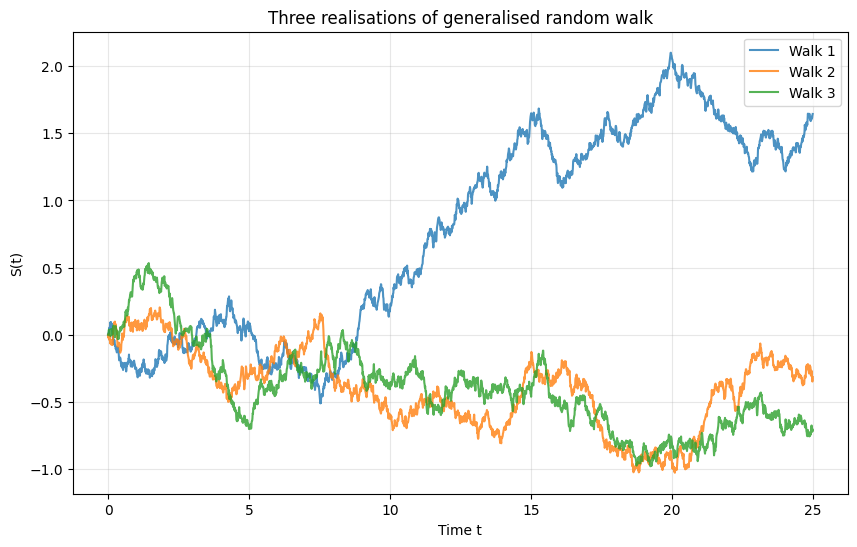

In [ ]:
#3C ---
import numpy as np
import matplotlib.pyplot as plt

alpha, beta = 3.45, 4.78
dt = 0.01
N = 2500
T = N * dt

def generalised_walk(alpha, beta, dt, N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    x = np.zeros(N+1)
    for i in range(N):
        t = i * dt
        drift = (1/alpha) * np.sin(x[i]) * np.cos(t) * dt
        diffusion = (1/beta) * np.random.normal(0, np.sqrt(dt))
        x[i+1] = x[i] + drift + diffusion
    return x

# Three realisations
x1 = generalised_walk(alpha, beta, dt, N, seed=42)
x2 = generalised_walk(alpha, beta, dt, N, seed=123)
x3 = generalised_walk(alpha, beta, dt, N, seed=999)

plt.figure(figsize=(10,6))
time = np.arange(N+1) * dt
plt.plot(time, x1, label='Walk 1', alpha=0.8)
plt.plot(time, x2, label='Walk 2', alpha=0.8)
plt.plot(time, x3, label='Walk 3', alpha=0.8)
plt.xlabel('Time t')
plt.ylabel('S(t)')
plt.title('Three realisations of generalised random walk')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


dt=0.01: mean final position = -0.0202
dt=0.05: mean final position = -0.0277
dt=0.10: mean final position = -0.1342
dt=0.20: mean final position = 0.0496
dt=0.40: mean final position = 0.0051


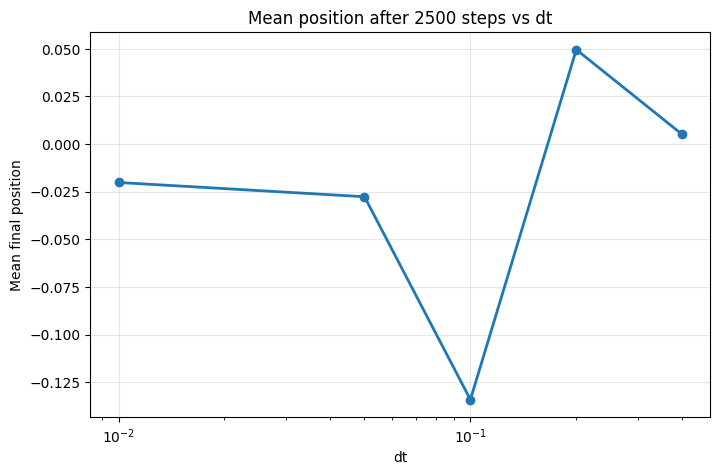

In [ ]:
#3D ---
dt_values = [0.01, 0.05, 0.1, 0.2, 0.4]
n_walks = 1000

mean_positions = []
for dt in dt_values:
    walks = [generalised_walk(alpha, beta, dt, N) for _ in range(n_walks)]
    final_positions = np.array([walk[-1] for walk in walks])
    mean_pos = np.mean(final_positions)
    mean_positions.append(mean_pos)
    print(f"dt={dt:4.2f}: mean final position = {mean_pos:.4f}")

plt.figure(figsize=(8,5))
plt.semilogx(dt_values, mean_positions, 'o-', linewidth=2)
plt.xlabel('dt')
plt.ylabel('Mean final position')
plt.title('Mean position after 2500 steps vs dt')
plt.grid(True, alpha=0.3)
plt.show()


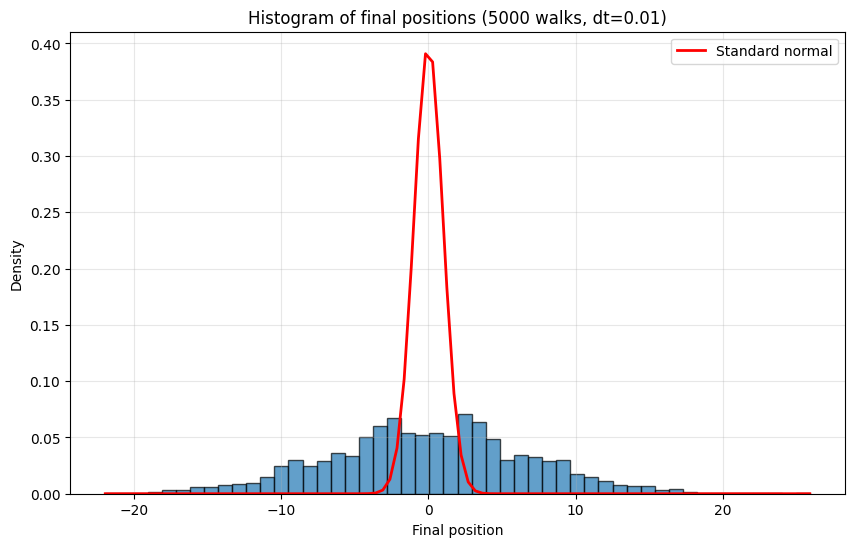

In [ ]:
#3E---
n_walks_hist = 5000
final_positions = [generalised_walk(alpha, beta, dt, N)[-1] for _ in range(n_walks_hist)]

plt.figure(figsize=(10,6))
plt.hist(final_positions, bins=50, density=True, alpha=0.7, edgecolor='black')
x_grid = np.linspace(min(final_positions), max(final_positions), 100)
plt.plot(x_grid, 1/np.sqrt(2*np.pi) * np.exp(-0.5 * x_grid**2), 'r-', linewidth=2, label='Standard normal')
plt.xlabel('Final position')
plt.ylabel('Density')
plt.title('Histogram of final positions (5000 walks, dt=0.01)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
#NORMALITY--
from scipy.stats import shapiro, normaltest

stat, p_value = shapiro(final_positions[:5000])  # Shapiro max 5000 samples
print(f"Shapiro-Wilk: stat={stat:.4f}, p={p_value:.4f}")

# D'Agostino normality test (larger sample OK)
stat2, p_value2 = normaltest(final_positions)
print(f"D'Agostino: stat={stat2:.4f}, p={p_value2:.4f}")


Shapiro-Wilk: stat=0.9991, p=0.0067
D'Agostino: stat=1.6643, p=0.4351


In [ ]:
#3F--
def prob_bounded(alpha, beta, dt, N, n_walks=10000):
    walks = [generalised_walk(alpha, beta, dt, N)[-1] for _ in range(n_walks)]
    return np.mean(np.abs(np.array(walks)) <= 2)

# dt=0.01
p_001 = prob_bounded(alpha, beta, 0.01, 500)

# Vary steps
steps = [100, 500, 1500, 2000]
probs = [prob_bounded(alpha, beta, 0.01, s) for s in steps]

print(f"P(|S|<=2 | dt=0.01, 500 steps) = {p_001:.4f}")
print("vs steps:", dict(zip(steps, probs)))


KeyboardInterrupt: 

In [ ]:
#4---


In [ ]:
#4B---
if f_proposal > f_current:


NameError: name 'f_proposal' is not defined

In [ ]:
alpha = min(1, f_proposal / f_current)  # MH acceptance ratio
if np.random.uniform() < alpha:
    x_current = x_proposal
    f_current = f_proposal


NameError: name 'f_proposal' is not defined

In [ ]:
#4--
def f(w, x, y, z):
    himmel1 = -((w**2 + x - 11)**2 + (w + x**2 - 7)**2)/100
    himmel2 = -((y**2 + z - 11)**2 + (y + z**2 - 7)**2)/100
    peak1 = 4.0 * np.exp(-0.2 * ((w-2.5)**2 + (x-1.8)**2 + (y+1.2)**2 + (z-0.7)**2))
    peak2 = 3.8 * np.exp(-0.18 * ((w+1.8)**2 + (x-2.2)**2 + (y-2.5)**2 + (z+1.5)**2))
    peak3 = 3.5 * np.exp(-0.22 * ((w-0.5)**2 + (x+2.8)**2 + (y-1.8)**2 + (z+2.3)**2))
    peak4 = 3.3 * np.exp(-0.25 * ((w+2.2)**2 + (x+0.8)**2 + (y+2.5)**2 + (z-2.1)**2))
    interaction = 0.2 * np.sin(w + x) * np.cos(y - z)
    return himmel1 + himmel2 + peak1 + peak2 + peak3 + peak4 + interaction


In [ ]:
def metropolis_hastings(f, x_init, sigma=0.5, n_steps=10000, seed=None):
    if seed is not None:
        np.random.seed(seed)

    x_current = np.array(x_init)
    f_current = f(*x_current)

    history = [f_current]
    accepts = 0

    for i in range(n_steps):
        x_proposal = x_current + np.random.normal(0, sigma, size=4)
        # Clip to bounds [-3.5, 3.5]
        x_proposal = np.clip(x_proposal, -3.5, 3.5)
        f_proposal = f(*x_proposal)

        # MH acceptance ratio
        alpha = min(1.0, f_proposal / f_current)
        if np.random.uniform() < alpha:
            x_current = x_proposal
            f_current = f_proposal
            accepts += 1

    accept_ratio = accepts / n_steps
    return x_current, history, accept_ratio


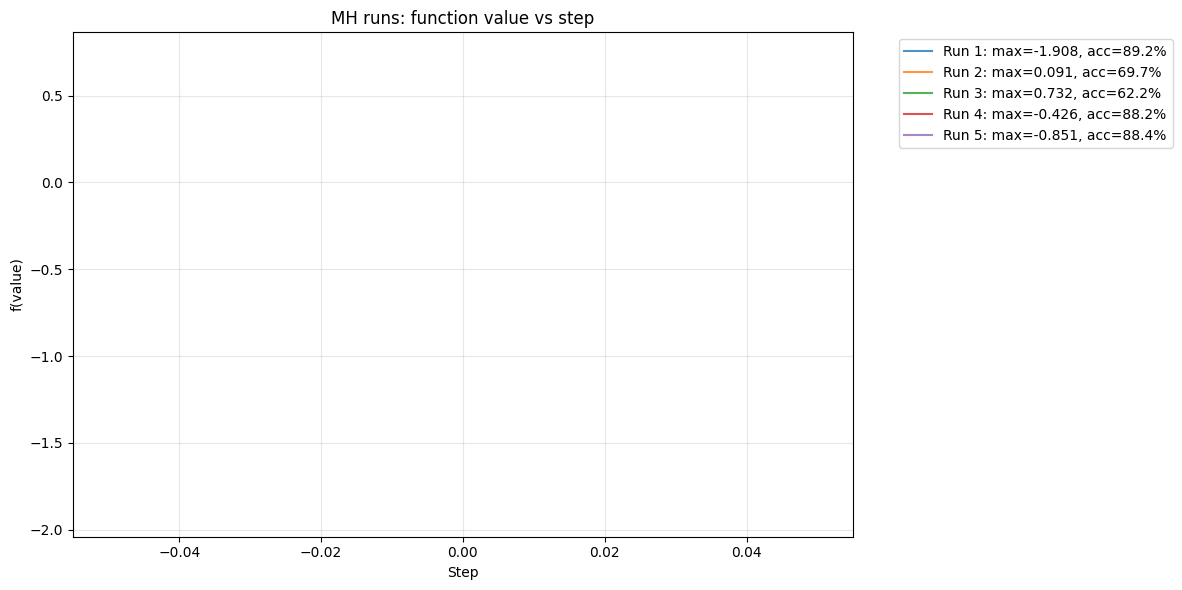

Run 1: final pos = [-0.892 -3.114  1.383  1.004], max f = -1.9079, acc = 89.2%
Run 2: final pos = [-2.403  2.614  1.015 -0.395], max f = 0.0909, acc = 69.7%
Run 3: final pos = [ 2.568  1.982 -0.958  1.106], max f = 0.7318, acc = 62.2%
Run 4: final pos = [ 1.886 -3.5    2.73   0.897], max f = -0.4263, acc = 88.2%
Run 5: final pos = [ 1.308 -1.534  0.067  2.23 ], max f = -0.8512, acc = 88.4%


In [ ]:
seeds = [42, 123, 456, 789, 999]
starts = [np.random.uniform(-3.5, 3.5, 4) for _ in range(5)]  # Random starts
results = []

plt.figure(figsize=(12,6))
for i, (seed, start) in enumerate(zip(seeds, starts)):
    pos, hist, acc = metropolis_hastings(f, start, sigma=0.5, n_steps=5000, seed=seed)
    results.append((pos, hist[-1], acc))

    plt.plot(hist, label=f'Run {i+1}: max={hist[-1]:.3f}, acc={acc:.1%}', alpha=0.8)

plt.xlabel('Step')
plt.ylabel('f(value)')
plt.title('MH runs: function value vs step')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Report results
for i, (pos, max_val, acc) in enumerate(results):
    print(f"Run {i+1}: final pos = {pos.round(3)}, max f = {max_val:.4f}, acc = {acc:.1%}")
